<a href="https://colab.research.google.com/github/JhonC07/ChallengeTelecomXAnalisisEvasionClientesAlura/blob/main/ChallengeAnalisisEvasionClientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Extracción de Datos (ETL - Extract)

In [89]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [90]:
# Aplanar columnas anidadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])
# Eliminar columnas originales
df = df.drop(columns=['customer','phone','internet','account'])
# Unir todo
df = pd.concat([df, customer_df, phone_df, internet_df, account_df], axis=1)


In [91]:
#Ver nombres columnas
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [92]:

#Convertir Charges.Total a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
#Verificar si se generaron nulos
df['Charges.Total'].isnull().sum()

np.int64(11)

In [93]:
#Ver los clientes afectados
df[df['Charges.Total'].isnull()][['tenure','Charges.Monthly']]

,tenure,Charges.Monthly
975,0,56.05
1775,0,20.00
1955,0,61.90
2075,0,19.70
2232,0,20.25
2308,0,25.35
2930,0,73.35
3134,0,25.75
3203,0,52.55
4169,0,80.85


In [94]:
#Corregir la insconsistencia
df.loc[
    (df['Charges.Total'].isnull()) & (df['tenure'] == 0),
    'Charges.Total'
] = 0

In [95]:
#Verificar nuevamente
df['Charges.Total'].isnull().sum()

np.int64(0)

#2. Conociendo el conjunto de datos

In [96]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#3. Comprobación de incoherencias en los datos

In [97]:
##3.1. Valores Nulos

df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [98]:
##3.2. Valores duplicados
df.duplicated(subset='customerID').sum()

np.int64(0)

In [99]:
##3.3. Valores únicos
df['Churn'].unique()
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

#4. Manejo de inconsistencias

In [100]:
##4.1. Verificar
if df['Charges.Total'].dtype == 'object':
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [101]:
##4.2. Evaluar impacto de la conversión
nulos_total = df['Charges.Total'].isnull().sum()

if nulos_total > 0:
    print(f"Se generaron {nulos_total} valores nulos en Charges.Total tras la conversión.")
else:
    print("No se generaron valores nulos tras la conversión.")

No se generaron valores nulos tras la conversión.


In [102]:
##4.3. Clientes recien ingresados
df[df['Charges.Total'].isnull()][['tenure', 'Charges.Monthly']]

,tenure,Charges.Monthly


In [103]:
##4.4. Corrección
df.loc[
    (df['Charges.Total'].isnull()) & (df['tenure'] == 0),
    'Charges.Total'
] = 0

In [104]:
##4.5. Validar nuevamente
df['Charges.Total'].isnull().sum()

np.int64(0)

In [105]:
##4.6. Versión Automática
import numpy as np
import pandas as pd

def limpiar_charges_total(df):

    print("🔎 Iniciando validación de Charges.Total...\n")

    ### 4.6.1. Convertir a numérico si es necesario
    if df['Charges.Total'].dtype == 'object':
        df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
        print("✔ Charges.Total convertido a numérico.")

    # 4.6.2. Contar nulos generados
    nulos = df['Charges.Total'].isnull().sum()
    print(f"📊 Valores nulos detectados: {nulos}")

    # 4.6.3. Corregir nulos donde tenure = 0
    condicion = (df['Charges.Total'].isnull()) & (df['tenure'] == 0)
    corregidos = condicion.sum()

    if corregidos > 0:
        df.loc[condicion, 'Charges.Total'] = 0
        print(f"✔ Se corrigieron {corregidos} registros con tenure = 0.")

    # 4.6.4. Verificar inconsistencias matemáticas
    diferencia = np.abs(df['Charges.Total'] - (df['Charges.Monthly'] * df['tenure']))
    inconsistencias = (diferencia > 1).sum()

    print(f"⚠ Inconsistencias detectadas en cálculo Total ≈ Monthly × Tenure: {inconsistencias}")

    print("\n✅ Validación final completada.")

    return df

In [106]:
##4.7. Limpiar datos
df = limpiar_charges_total(df)

🔎 Iniciando validación de Charges.Total...

📊 Valores nulos detectados: 0
⚠ Inconsistencias detectadas en cálculo Total ≈ Monthly × Tenure: 6491

✅ Validación final completada.


#5. Creación de la Columna Cuentas_Diarias

Calcular el valor promedio diario pagado por cada cliente a partir de Cuentas_Diarias = (Charges.Monthly​/30)

Esto permite:

* Analizar sensibilidad al precio
* Comparar churn por costo diario
* Generar mejores visualizaciones
* Facilitar modelos predictivos

In [107]:
#Crear columnas cuentas diarias
df['cuentas_diarias'] = df['Charges.Monthly'] / 30
#Verificación
df[['Charges.Monthly','cuentas_diarias']].head()


,Charges.Monthly,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


#6. Estandarización y Transformación de Datos
* Convertir variables categóricas binarias a formato numérico (0/1)
* Renombrar columnas para mayor claridad
* Preparar el dataset para análisis estadístico y modelos predictivos

In [108]:
#Ver los valores
df['Churn'].unique()
df['Partner'].unique()
df['Dependents'].unique()

array(['Yes', 'No'], dtype=object)

In [109]:
##6.1. Estandarizar variables binarias (Yes/No → 1/0)

df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()

df['Churn'] = df['Churn'].map({
    'yes': 1,
    'no': 0
})
df['Partner'] = df['Partner'].map({'Yes':1,'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1,'No':0})
df['PhoneService'] = df['PhoneService'].map({'Yes':1,'No':0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1,'No':0})

In [110]:
df['Churn'].isnull().sum()
df = df.dropna(subset=['Churn'])
df['Churn'] = df['Churn'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

#7. Análisis Descriptivo

In [113]:
#Generar el análisis descriptivo
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [114]:
df.describe(include='all')

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,cuentas_diarias
count,7043,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043,...,7043,7043,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043.000000
unique,7043,NaN,2,NaN,NaN,NaN,NaN,NaN,3,3,...,3,3,3,3,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,Male,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,...,No,No,No,No,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,3555,NaN,NaN,NaN,NaN,NaN,3390,3096,...,3095,3473,2810,2785,3875,NaN,2365,NaN,NaN,NaN
mean,NaN,0.265370,NaN,0.162147,0.483033,0.299588,32.371149,0.903166,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.592219,NaN,64.761692,2279.734304,2.158723
std,NaN,0.441561,NaN,0.368612,0.499748,0.458110,24.559481,0.295752,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491457,NaN,30.090047,2266.794470,1.003002
min,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,0.000000,0.608333
25%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.500000,398.550000,1.183333
50%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.350000,1394.550000,2.345000
75%,NaN,1.000000,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.850000,3786.600000,2.995000


#8. Distribución de evasión (Churn)

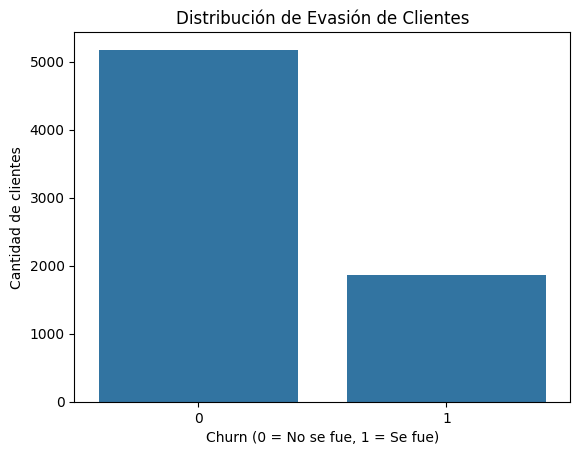

In [115]:
#Gráfico de barras
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)

plt.title('Distribución de Evasión de Clientes')
plt.xlabel('Churn (0 = No se fue, 1 = Se fue)')
plt.ylabel('Cantidad de clientes')

plt.show()

In [116]:
#Ver porcentaje
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


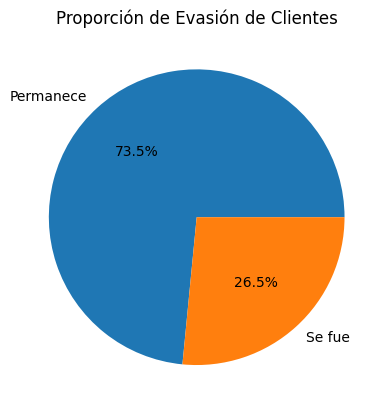

In [117]:
#Gráfico Pastel
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Permanece', 'Se fue']
)

plt.title('Proporción de Evasión de Clientes')
plt.ylabel('')
plt.show()

#9. Regresión por variables

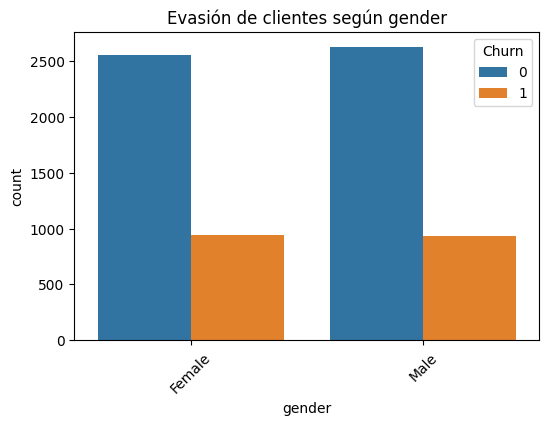

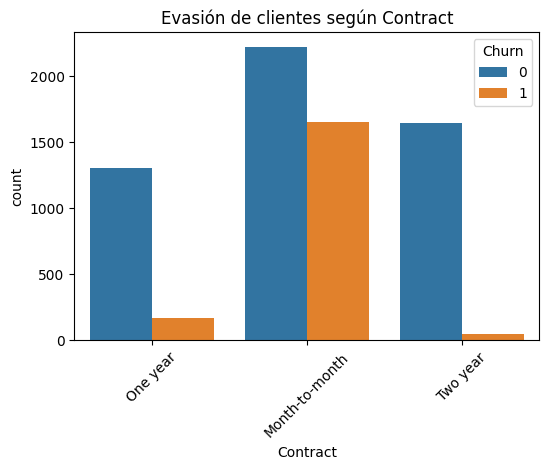

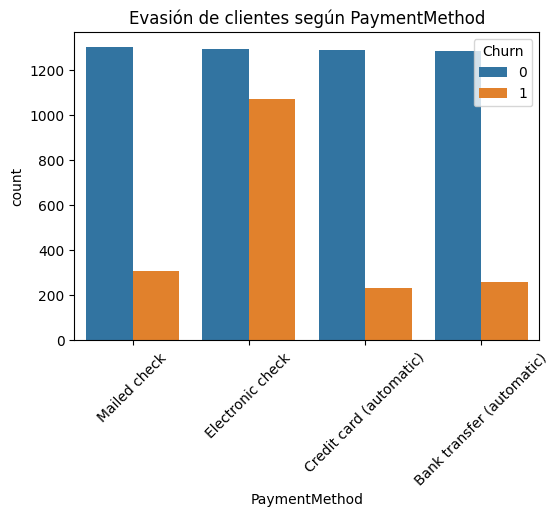

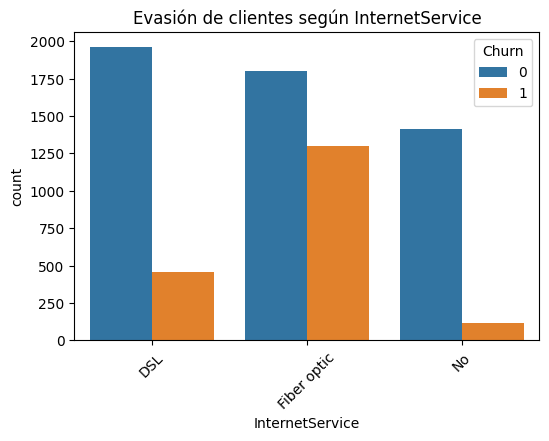

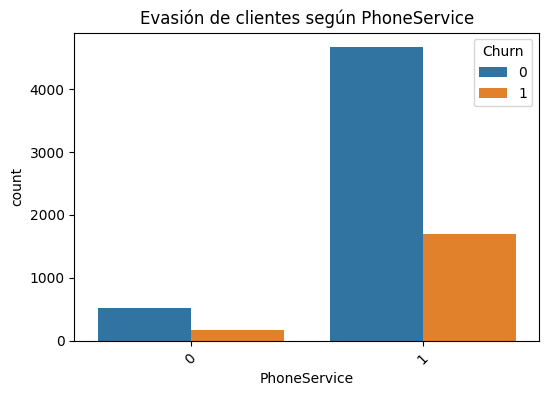

In [120]:
#Lista de variables categoricas


import matplotlib.pyplot as plt
import seaborn as sns

variables_categoricas = [
    'gender',
    'Contract',
    'PaymentMethod',
    'InternetService',
    'PhoneService'
]

for col in variables_categoricas:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        hue='Churn'
    )

    plt.title(f'Evasión de clientes según {col}')
    plt.xticks(rotation=45)

    plt.show()

In [124]:
def tabla_churn(df, columna):

    conteo = pd.crosstab(df[columna], df['Churn'])
    porcentaje = pd.crosstab(df[columna], df['Churn'], normalize='index')*100

    tabla = conteo.astype(str) + " (" + porcentaje.round(2).astype(str) + "%)"

    return tabla


columnas = ['Contract','PaymentMethod','InternetService','gender']

for col in columnas:
    print("\n==============================")
    print(f"Tabla de Churn por {col}")
    print("==============================")
    print(tabla_churn(df, col))


Tabla de Churn por Contract
Churn                       0              1
Contract                                    
Month-to-month  2220 (57.29%)  1655 (42.71%)
One year        1307 (88.73%)   166 (11.27%)
Two year        1647 (97.17%)     48 (2.83%)

Tabla de Churn por PaymentMethod
Churn                                  0              1
PaymentMethod                                          
Bank transfer (automatic)  1286 (83.29%)   258 (16.71%)
Credit card (automatic)    1290 (84.76%)   232 (15.24%)
Electronic check           1294 (54.71%)  1071 (45.29%)
Mailed check               1304 (80.89%)   308 (19.11%)

Tabla de Churn por InternetService
Churn                        0              1
InternetService                              
DSL              1962 (81.04%)   459 (18.96%)
Fiber optic      1799 (58.11%)  1297 (41.89%)
No                1413 (92.6%)     113 (7.4%)

Tabla de Churn por gender
Churn               0             1
gender                             
Female  254

In [125]:
columnas = ['Contract','PaymentMethod','InternetService','gender']

tablas = []

for col in columnas:
    tabla = tabla_churn(df, col)
    tabla['variable'] = col      # identificar de qué variable viene
    tablas.append(tabla)

resultado = pd.concat(tablas)

resultado

Churn,0,1,variable
Month-to-month,2220 (57.29%),1655 (42.71%),Contract
One year,1307 (88.73%),166 (11.27%),Contract
Two year,1647 (97.17%),48 (2.83%),Contract
Bank transfer (automatic),1286 (83.29%),258 (16.71%),PaymentMethod
Credit card (automatic),1290 (84.76%),232 (15.24%),PaymentMethod
Electronic check,1294 (54.71%),1071 (45.29%),PaymentMethod
Mailed check,1304 (80.89%),308 (19.11%),PaymentMethod
DSL,1962 (81.04%),459 (18.96%),InternetService
Fiber optic,1799 (58.11%),1297 (41.89%),InternetService
No,1413 (92.6%),113 (7.4%),InternetService


In [126]:
resultado.to_csv("analisis_churn_categorias.csv")

#10. Conteo de evasión por variables numéricas

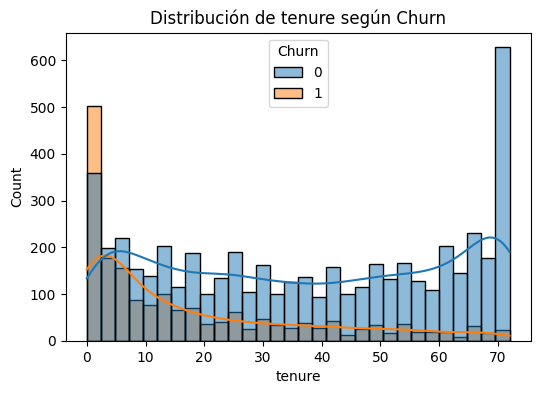

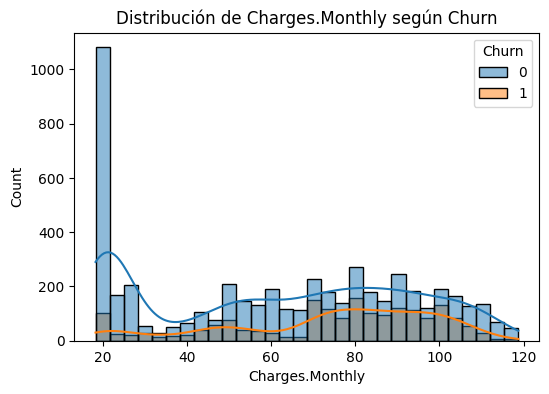

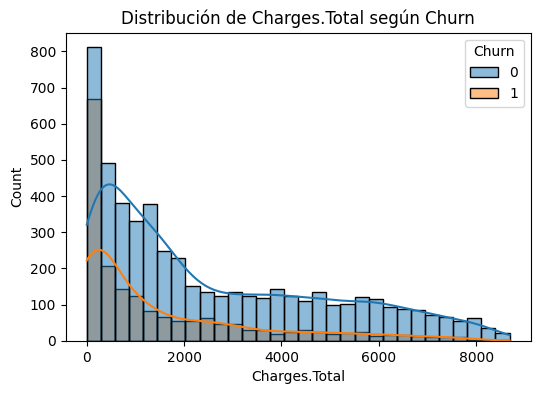

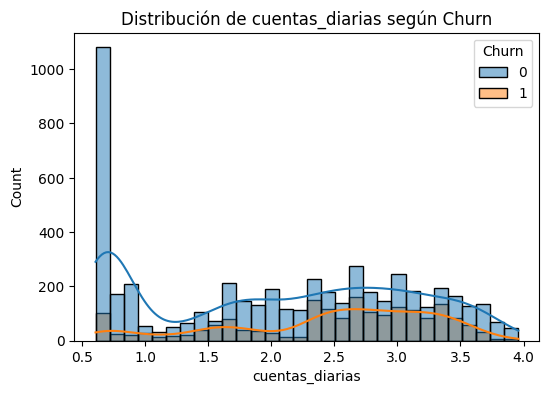

In [127]:
# Identificar variables númericas
variables_numericas = [
    'tenure',
    'Charges.Monthly',
    'Charges.Total',
    'cuentas_diarias'
]
#Distribución con Histogramas
import seaborn as sns
import matplotlib.pyplot as plt

for col in variables_numericas:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        bins=30,
        kde=True
    )

    plt.title(f'Distribución de {col} según Churn')
    plt.show()

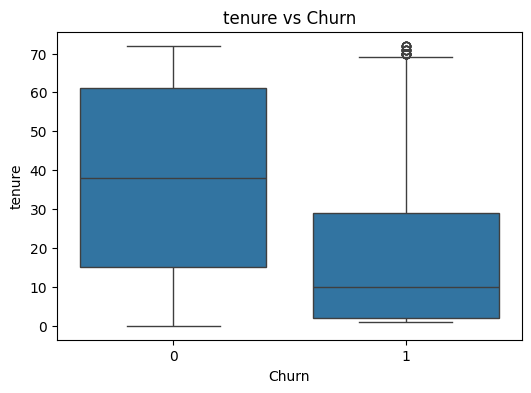

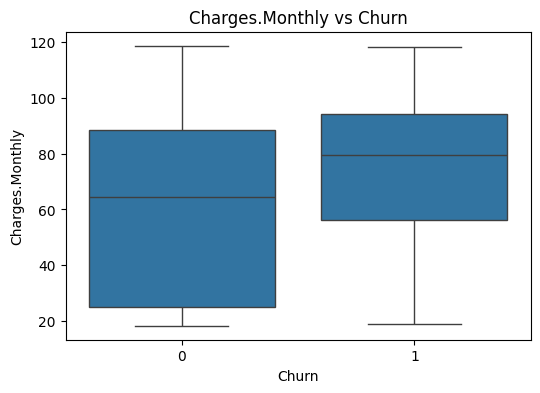

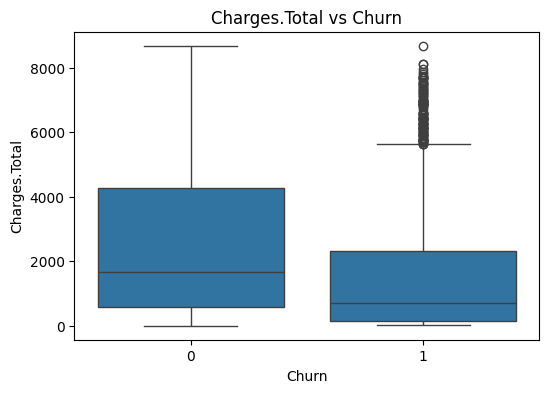

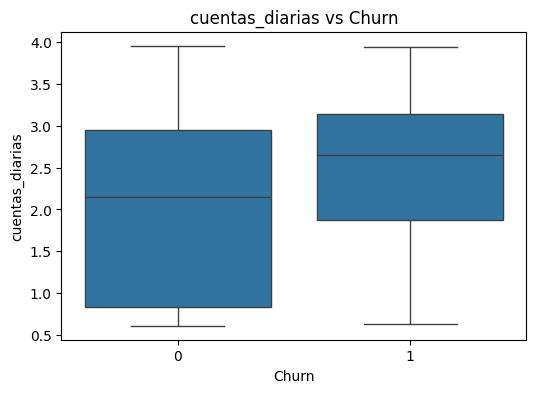

In [128]:
#Comparación con Boxplot
for col in variables_numericas:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x='Churn',
        y=col
    )

    plt.title(f'{col} vs Churn')
    plt.show()

In [129]:
#Tabla descriptiva por churn
df.groupby('Churn')[variables_numericas].describe()


tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
0      5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      Charges.Monthly             ... Charges.Total          cuentas_diarias  \
                count       mean  ...           75%      max           count   
Churn                             ...                                          
0              5174.0  61.265124  ...       4262.85  8672.45          5174.0   
1              1869.0  74.441332  ...       2331.30  8684.80          1869.0   

                                                                           
           mean       std       min       25%     50%       75%       max  
Churn                                                                      
0      2.042171  1.036422  0.608333  0.836667  2.1475  2.946667  3.958333  
1      2.481378  0.822202  0.628333  1.871667  2.6550  3.140000  3.945000  

[2 rows x 32 columns]